In [21]:
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt

In [49]:
test_nc = xr.open_dataset('Material_ENSO\monthClima\AQUA_MODIS.20020701_20190731.L3m.MC.SST4.sst4.4km.nc')

In [50]:
test_nc

<xarray.Dataset> Size: 299MB
Dimensions:    (lat: 4320, lon: 8640, rgb: 3, eightbitcolor: 256)
Coordinates:
  * lat        (lat) float32 17kB 89.98 89.94 89.9 89.85 ... -89.9 -89.94 -89.98
  * lon        (lon) float32 35kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
Dimensions without coordinates: rgb, eightbitcolor
Data variables:
    sst4       (lat, lon) float32 149MB ...
    qual_sst4  (lat, lon) float32 149MB ...
    palette    (rgb, eightbitcolor) uint8 768B ...
Attributes: (12/59)
    product_name:                     AQUA_MODIS.20020701_20190731.L3m.MC.SST...
    instrument:                       MODIS
    title:                            MODISA Level-3 Standard Mapped Image
    project:                          Ocean Biology Processing Group (NASA/GS...
    platform:                         Aqua
    temporal_range:                   17-year
    ...                               ...
    publisher_url:                    https://oceandata.sci.gsfc.nasa.gov
    processing_level:                 L3 Mapped
    cdm_data_type:                    grid
    data_bins:                        19374136
    data_minimum:                     -1.6850001
    data_maximum:                     36.565

In [ ]:
#test_nc['lon'] = test_nc['lon'] - 90

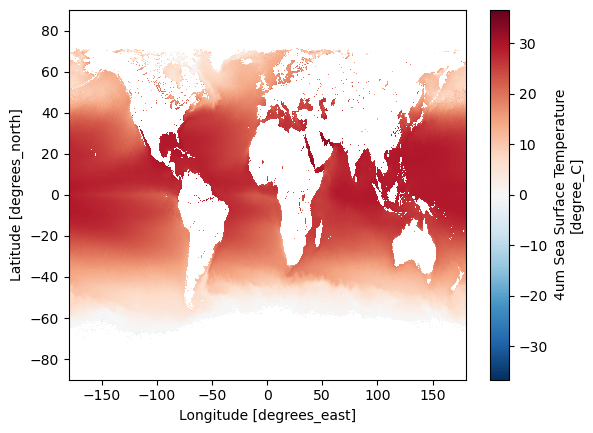

In [54]:
test_nc.sst4.plot()

In [59]:
vector_test = gpd.read_file('Material_ENSO\ONI_region\ONI_zone1.shp', set_crs = 'EPSG:4326')

c:\Users\win10\anaconda3\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: driver ESRI Shapefile does not support open option SET_CRS
  return ogr_read(


<Axes: >

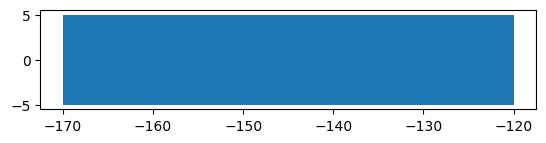

In [60]:
vector_test.plot()

In [ ]:
minx, miny, maxx, maxy = vector_test.bounds.iloc[0, :]

In [55]:
test_nc_slc = test_nc.sel(lat=slice(miny, maxy), lon=slice(minx, maxx))

<Axes: xlabel='Longitude [degrees_east]', ylabel='Latitude [degrees_north]'>

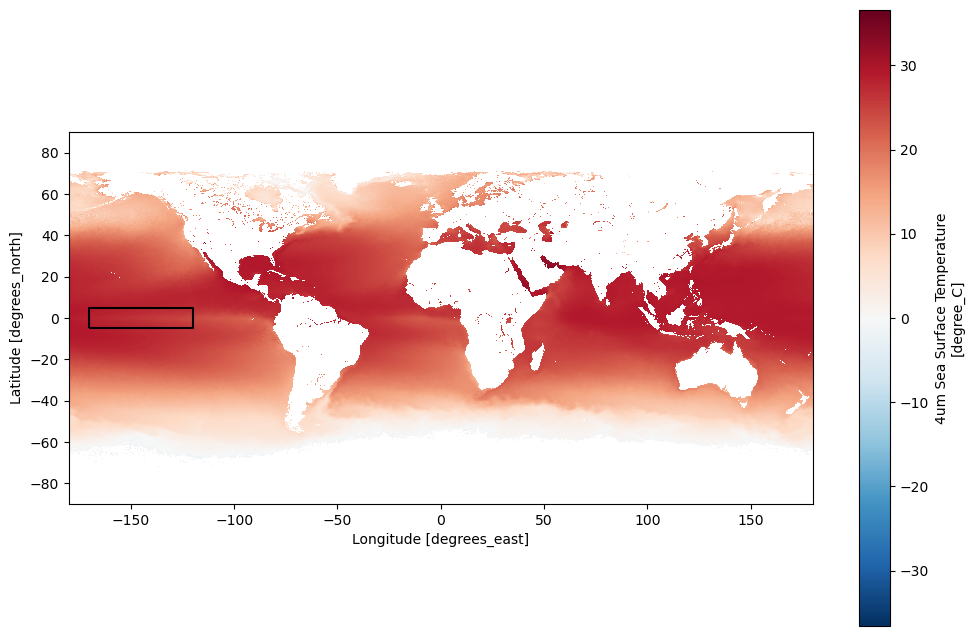

In [61]:
fig, ax = plt.subplots(figsize=(12, 8))
test_nc.sst4.plot(ax=ax)
vector_test.boundary.plot(ax=ax, edgecolor='black')



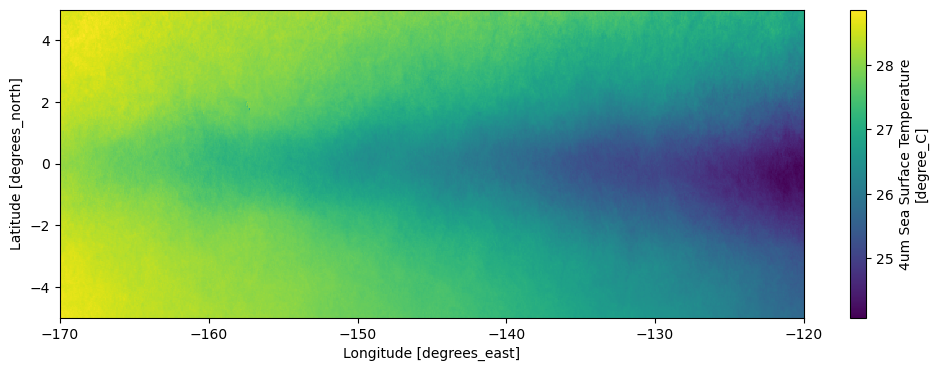

In [69]:
fig, ax = plt.subplots(figsize=(12, 4))
test_nc_sel = test_nc.sel(lat=slice(maxy, miny), lon=slice(minx, maxx))
test_nc_sel.sst4.plot(ax=ax)

In [32]:
minx, miny, maxx, maxy

(-170.0, -5.0, -120.0, 5.0)